## Chi Square Testing

### Question: Is payment type associated with order status?

### Hypotheses
##### H0: Payment type and order status are independent (no association).
##### H1: Payment type and order status are dependent (there is a significant association).

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from configs.settings import project_dir
from scipy.stats import chi2_contingency
import seaborn as sns

In [28]:
p_dir = project_dir()
featured_dir_path = p_dir.FEATURE_ENGINEERED
cleaned_dir_path = p_dir.CLEANED_DIR

orders_f = pd.read_csv(featured_dir_path / 'featured_orders.csv')
payments = pd.read_csv(cleaned_dir_path / 'cleaned_order_payments.csv',index_col=0)

In [29]:
df_payments = pd.merge(payments, orders_f[['order_id', 'order_status']], on='order_id', how='inner')

In [30]:
df_payments.sample(3)

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_status
81702,afb829d86325360c29829a3fb2c15a8e,1,wallet,1,139.98,delivered
101195,c3ea366b4645392afd2903b2955a5151,1,credit_card,3,177.99,delivered
1305,363fe8f62de97e4334f5c88e3d9e73a8,1,credit_card,1,89.91,delivered


In [31]:
# Create contingency table
contingency = pd.crosstab(df_payments['payment_type'], df_payments['order_status'])

display(contingency)

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
credit_card,2,447,3,74586,239,224,851,446
debit_card,0,7,0,1486,6,2,22,6
voucher,0,115,0,5493,13,23,84,47
wallet,0,95,2,19191,67,70,209,150


In [32]:
# Cell 4: Run Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency)

In [33]:
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"p-value: {p_value}")
print(f"Degrees of Freedom: {dof}")

Chi2 Statistic: 210.1640
p-value: 3.583963858634613e-33
Degrees of Freedom: 21


In [34]:
if p_value < 0.05:
    print("\nConclusion: Reject H0. Payment type is significantly associated with order status.")
else:
    print("\nConclusion: Fail to reject H0. No significant association between payment type and order status.")


Conclusion: Reject H0. Payment type is significantly associated with order status.


## Visualization

In [35]:
contingency_pct = pd.crosstab(
    df_payments['payment_type'], 
    df_payments['order_status'], 
    normalize='index'
)

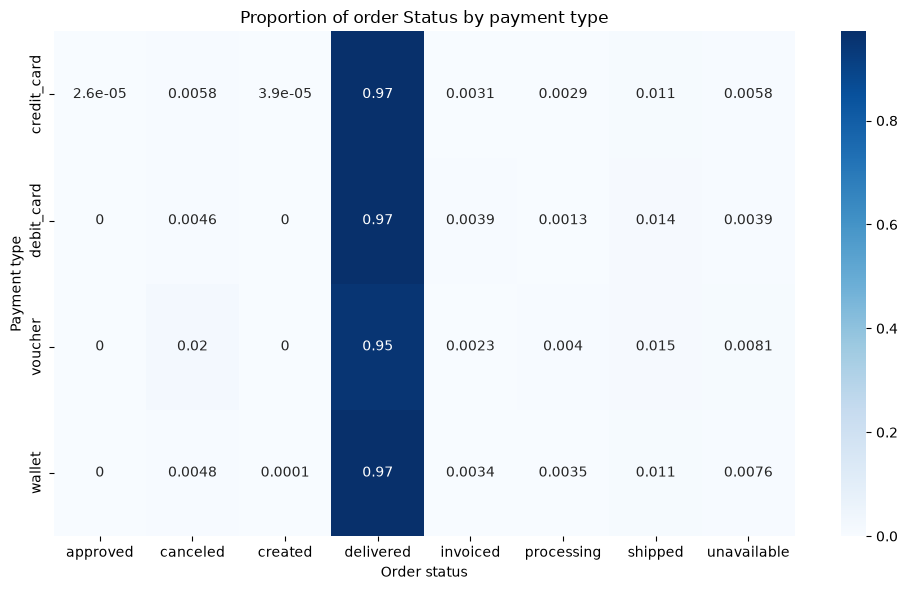

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(contingency_pct, annot=True,cmap='Blues')
plt.title("Proportion of order Status by payment type")
plt.xlabel("Order status")
plt.ylabel("Payment type")
plt.tight_layout()
plt.show()